# Language Models for Text Classification 

## 0. Setup

In [53]:
import os
import re
import time
import pandas as pd
import matplotlib.pyplot as plt
from openai import OpenAI
from groq import Groq
from mistralai.client import Mistral
from sklearn.model_selection import train_test_split


In [54]:
%env GROQ_API_KEY='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'
%env MISTRAL_API_KEY='pojygBcty1joDr7csFHKQIJTVFHQCRTX'

env: GROQ_API_KEY='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'
env: MISTRAL_API_KEY='pojygBcty1joDr7csFHKQIJTVFHQCRTX'


In [55]:
SEED = 2026

# Small subsets keep the demo fast and avoid exhausting free quotas.
TRAIN_SUBSET = 50
TEST_SUBSET = 50

LABELS = [
    "Anthropic",
    "Google",
    "Human",
    "Meta",
    "OpenAI"
]

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
MISTRAL_API_KEY = os.getenv("MISTRAL_API_KEY")

print(f"Groq key loaded: {GROQ_API_KEY is not None}")
print(f"Mistral key loaded: {MISTRAL_API_KEY is not None}")

#Groq Models
GROQ_MODEL1 = "llama-3.1-8b-instant"
GROQ_MODEL2 = "llama-3.3-70b-versatile"

#Mistral Models
MISTRAL_MODEL1 = "mistral-large-latest"
MISTRAL_MODEL2 = "mistral-medium"
MISTRAL_MODEL3 = "mistral-large"



#OPENAI_MODEL = "gpt-4o-mini"

# groq_client = Groq(api_key=GROQ_API_KEY)
# mistral_client = Mistral(api_key=MISTRAL_API_KEY)

groq_client = Groq(api_key='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')
mistral_client = Mistral(api_key='pojygBcty1joDr7csFHKQIJTVFHQCRTX')

Groq key loaded: True
Mistral key loaded: True


## 1. Carregamento e Pré-processamento dos Dados

In [58]:
df = pd.read_csv("data/train.csv", sep=";")

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    return text.strip()

df["clean_text"] = df["Text"].apply(clean_text)

df_train, df_test = train_test_split(df, test_size=0.5, random_state=SEED, stratify=df["Label"])

#  reduzir custo API
df_train = df_train.sample(n=TRAIN_SUBSET, random_state=SEED)
df_test = df_test.sample(n=TEST_SUBSET, random_state=SEED)

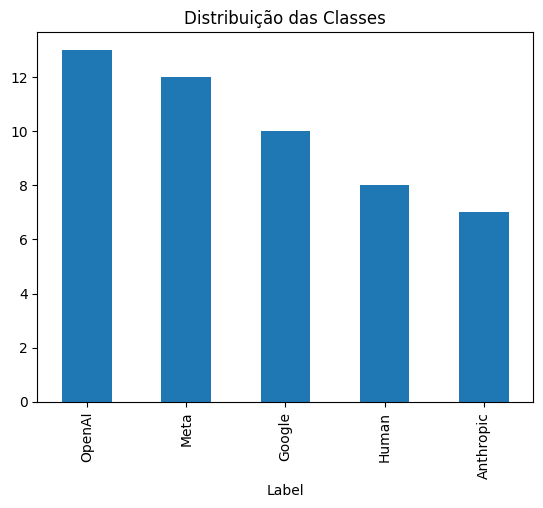

In [59]:
df_train["Label"].value_counts().plot(kind="bar", title="Distribuição das Classes")
plt.show()

## 2. Build prompts

Definição do *prompt* para classificar textos.

zero-shot vs few-shot

In [60]:
def build_zero_shot_prompt(example):
    prompt = f"""
You are a strict classifier.

Possible labels:
Anthropic, Google, Human, Meta, OpenAI

Return ONLY one label.

Text:\n
{example["clean_text"]}
"""
    return prompt.strip()

In [61]:
support_examples = df_train.sample(n=5, random_state=SEED).to_dict(orient="records")

def format_example(ex):
    return f"""
Text: "{ex["clean_text"]}"
Label: {ex["Label"]}
"""

def build_few_shot_prompt(example, support_examples):
    support_block = ""

    for support_example in support_examples:
        support_block += format_example(support_example)
    
    prompt = f"""
You are a text classifier.

Possible labels:
Anthropic, Google, Human, Meta, OpenAI

Examples:
{support_block}

Now classify:

Text:
{example["clean_text"]}

Return ONE and ONLY label.
"""
    return prompt.strip()

## 3. API helpers

In [62]:
def ask_groq(prompt, model=GROQ_MODEL1):
    response = groq_client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
        max_tokens=10,
    )
    
    print(response)

    return response.choices[0].message.content

In [63]:
def ask_mistral(prompt, model=MISTRAL_MODEL1):
    response = mistral_client.chat.complete(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
        max_tokens=10,
    )
    
    print(response)

    return response.choices[0].message.content

In [64]:
VALID_LABELS = set(LABELS)

def normalize_prediction(text):
    if text is None:
        return None

    text = text.strip()

    if text in VALID_LABELS:
        return text

    for label in VALID_LABELS:
        if label.lower() in text.lower():
            return label
            
    return None

In [65]:
def evaluate_predictions(predictions, gold_labels):
    rows = []
    for gold_label, prediction in zip(gold_labels, predictions):
        rows.append({
            "gold_label": gold_label,
            "prediction": prediction,
            "correct":    prediction == gold_label,
        })
    return pd.DataFrame(rows)

## 4. Zero-shot classification

In [ ]:
def run_experiment(
    dataset_split,
    ask_fn,
    model_name,
    prompt_builder,
    support_examples=None,
    sleep_seconds=0.8,
):

    predictions, raw_outputs = [], []

    for example in dataset_split:
        try:
            prompt = (
                prompt_builder(example, support_examples)
                if support_examples
                else prompt_builder(example)
            )
            raw  = ask_fn(prompt, model=model_name)
            pred = normalize_prediction(raw)
            raw_outputs.append(raw)
            predictions.append(pred)
        except Exception as e:
            print(f"Error: {e}")
            raw_outputs.append(None)
            predictions.append(None)

        time.sleep(sleep_seconds)

    return predictions, raw_outputs

In [67]:
gold_test = df_test["Label"].tolist()

zs_groq_preds1, zs_groq_raw1 = run_experiment(
    df_test.to_dict(orient="records"),
    ask_fn=ask_groq,
    model_name=GROQ_MODEL1,
    prompt_builder=build_zero_shot_prompt,
)

ChatCompletion(id='chatcmpl-cc8b390d-6bf0-4a88-9f2d-4f1f70c1d3ef', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='Human', role='assistant', annotations=None, executed_tools=None, function_call=None, reasoning=None, tool_calls=None))], created=1774441031, model='llama-3.1-8b-instant', object='chat.completion', mcp_list_tools=None, service_tier='on_demand', system_fingerprint='fp_6a1eabf260', usage=CompletionUsage(completion_tokens=2, prompt_tokens=154, total_tokens=156, completion_time=0.00743026, completion_tokens_details=None, prompt_time=0.009957299, prompt_tokens_details=None, queue_time=0.017888077, total_time=0.017387559), usage_breakdown=None, x_groq=XGroq(id='req_01kmjetsa0fchsvq1m5bf86srp', debug=None, seed=866254404, usage=None))
ChatCompletion(id='chatcmpl-11314964-0640-4107-8253-a52cff31848b', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='Human', role='assistant', ann

In [68]:
zs_groq_preds2, zs_groq_raw2 = run_experiment(
    df_test.to_dict(orient="records"),
    ask_fn=ask_groq,
    model_name=GROQ_MODEL2,
    prompt_builder=build_zero_shot_prompt,
)

ChatCompletion(id='chatcmpl-4a3579a7-a392-4e0c-995a-4d494fc5912e', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='OpenAI', role='assistant', annotations=None, executed_tools=None, function_call=None, reasoning=None, tool_calls=None))], created=1774441161, model='llama-3.3-70b-versatile', object='chat.completion', mcp_list_tools=None, service_tier='on_demand', system_fingerprint='fp_dae98b5ecb', usage=CompletionUsage(completion_tokens=3, prompt_tokens=154, total_tokens=157, completion_time=0.015267246, completion_tokens_details=None, prompt_time=0.049544094, prompt_tokens_details=None, queue_time=0.147437273, total_time=0.06481134), usage_breakdown=None, x_groq=XGroq(id='req_01kmjeyr3ae5m9m2ppnyynwydr', debug=None, seed=509954617, usage=None))
ChatCompletion(id='chatcmpl-ca27b622-4dd9-47a0-a1e5-ba732a0e8324', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='Human', role='assistant',

In [79]:
groq_eval1 = evaluate_predictions(zs_groq_preds1, gold_test)
groq_eval2 = evaluate_predictions(zs_groq_preds2, gold_test)

print("Groq:")
display(groq_eval1)
display(groq_eval2)

Groq:


,gold_label,prediction,correct
0,Google,Human,False
1,OpenAI,Human,False
2,Anthropic,Human,False
3,Human,Human,True
4,Anthropic,Human,False
5,Meta,Human,False
6,OpenAI,Human,False
7,Anthropic,Meta,False
8,Anthropic,Human,False
9,Anthropic,Human,False


,gold_label,prediction,correct
0,Google,OpenAI,False
1,OpenAI,Human,False
2,Anthropic,Human,False
3,Human,Human,True
4,Anthropic,Human,False
5,Meta,OpenAI,False
6,OpenAI,OpenAI,True
7,Anthropic,Human,False
8,Anthropic,Human,False
9,Anthropic,Human,False


In [80]:
zs_mistral_preds1, zs_mistral_raw1 = run_experiment(
    df_test.to_dict(orient="records"),
    ask_fn=ask_mistral,
    model_name=MISTRAL_MODEL1,
    prompt_builder=build_zero_shot_prompt,
)

id='5124302c0bfc4d71829d3419a2b8e1b0' object='chat.completion' model='mistral-large-latest' usage=UsageInfo(prompt_tokens=124, completion_tokens=2, total_tokens=126, prompt_audio_seconds=Unset(), prompt_tokens_details={'cached_tokens': 0}) created=1774444922 choices=[ChatCompletionChoice(index=0, message=AssistantMessage(role='assistant', content='Human', tool_calls=None, prefix=False), finish_reason='stop')]
id='046292cf79904e6c96330531b5934a7a' object='chat.completion' model='mistral-large-latest' usage=UsageInfo(prompt_tokens=50, completion_tokens=2, total_tokens=52, prompt_audio_seconds=Unset(), prompt_tokens_details={'cached_tokens': 0}) created=1774444924 choices=[ChatCompletionChoice(index=0, message=AssistantMessage(role='assistant', content='Human', tool_calls=None, prefix=False), finish_reason='stop')]
id='bd82e0bddbd54872aeb32864463706dd' object='chat.completion' model='mistral-large-latest' usage=UsageInfo(prompt_tokens=54, completion_tokens=2, total_tokens=56, prompt_audio

In [78]:
zs_mistral_preds2, zs_mistral_raw2 = run_experiment(
    df_test.to_dict(orient="records"),
    ask_fn=ask_mistral,
    model_name=MISTRAL_MODEL2,
    prompt_builder=build_zero_shot_prompt,
    sleep_seconds=2,
)

id='46999e7c4fae440593114155c90bd482' object='chat.completion' model='mistral-medium' usage=UsageInfo(prompt_tokens=124, completion_tokens=2, total_tokens=126, prompt_audio_seconds=Unset(), prompt_tokens_details={'cached_tokens': 0}) created=1774444770 choices=[ChatCompletionChoice(index=0, message=AssistantMessage(role='assistant', content='Human', tool_calls=None, prefix=False), finish_reason='stop')]
id='192fcacdbfce4766b079577a43ce845f' object='chat.completion' model='mistral-medium' usage=UsageInfo(prompt_tokens=50, completion_tokens=2, total_tokens=52, prompt_audio_seconds=Unset(), prompt_tokens_details={'cached_tokens': 0}) created=1774444773 choices=[ChatCompletionChoice(index=0, message=AssistantMessage(role='assistant', content='Human', tool_calls=None, prefix=False), finish_reason='stop')]
id='34bf17ad8af648f799b451e80799d3f1' object='chat.completion' model='mistral-medium' usage=UsageInfo(prompt_tokens=54, completion_tokens=2, total_tokens=56, prompt_audio_seconds=Unset(), 

In [81]:
mistral_eval1 = evaluate_predictions(zs_mistral_preds1, gold_test)
mistral_eval2 = evaluate_predictions(zs_mistral_preds2, gold_test)

print("Mistral:")
display(mistral_eval1)
display(mistral_eval2)

Mistral:


,gold_label,prediction,correct
0,Google,Human,False
1,OpenAI,Human,False
2,Anthropic,Human,False
3,Human,Human,True
4,Anthropic,Human,False
5,Meta,Human,False
6,OpenAI,Human,False
7,Anthropic,Human,False
8,Anthropic,Human,False
9,Anthropic,Human,False


,gold_label,prediction,correct
0,Google,Human,False
1,OpenAI,Human,False
2,Anthropic,Human,False
3,Human,Human,True
4,Anthropic,Human,False
5,Meta,Human,False
6,OpenAI,Human,False
7,Anthropic,Human,False
8,Anthropic,Human,False
9,Anthropic,Human,False


## 5. Few-shot classification

In few-shot prompting, we include a small number of labeled examples in the prompt.

In [96]:
support_examples = []
support_examples1 = []
seen = set()
seen1 = set()
complete = False

for _, row in df_train.iterrows():
    label = row["Label"]
    
    if label not in seen:
        support_examples.append(row.to_dict())
        seen.add(label)
        continue
    
    if label not in seen1:
        support_examples1.append(row.to_dict())
        seen1.add(label)
    
    if len(seen) == len(LABELS) and len(seen1) == len(LABELS):
        break


for ex in support_examples:
    print(ex["Label"])
    print(format_example(ex))
    print("-" * 80)
            
for ex in support_examples1:
    print(ex["Label"])
    print(format_example(ex))
    print("-" * 80)

print(f"Support set size: {len(support_examples)} — Support set size1: {len(support_examples1)} - labels: {seen}\n")
    

Anthropic

Text: "having polar bonds may make a covalent compound polar"
Label: Anthropic

--------------------------------------------------------------------------------
Meta

Text: "the term  ghost sharks  refers to the deep sea chimaeras  which are cartilaginous fish characterized by their unique  filter feeding behavior and distinctive body shape  these ancient creatures have evolved over millions of years to thrive in the dark depths of the ocean  where they feed on plankton and small organisms  chimaeras possess a long snout and jaws lined with tiny teeth that help them capture prey"
Label: Meta

--------------------------------------------------------------------------------
Google

Text: "migration is the movement of animals from one place to another  it s often seasonal  driven by factors like food availability  breeding grounds  or climate  migration can be short distance or cover vast distances  as seen in birds  whales  and butterflies  it s a complex behavior often involv

In [41]:
gold_test = df_test["Label"].tolist()

fs_groq_preds1, fs_groq_raw = run_experiment(
    df_test.to_dict(orient="records"),
    ask_fn=ask_groq,
    model_name=GROQ_MODEL1,
    prompt_builder=build_few_shot_prompt,
    support_examples=support_examples,
)

ChatCompletion(id='chatcmpl-841b24d6-95ca-4233-8595-561b93c2bbf1', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='Anthropic', role='assistant', annotations=None, executed_tools=None, function_call=None, reasoning=None, tool_calls=None))], created=1774375677, model='llama-3.1-8b-instant', object='chat.completion', mcp_list_tools=None, service_tier='on_demand', system_fingerprint='fp_dd2ecd7b1d', usage=CompletionUsage(completion_tokens=3, prompt_tokens=572, total_tokens=575, completion_time=0.00751751, completion_tokens_details=None, prompt_time=0.035196581, prompt_tokens_details=None, queue_time=0.045168188, total_time=0.042714091), usage_breakdown=None, x_groq=XGroq(id='req_01kmgggb51fxz9by2vtvh2ayx7', debug=None, seed=972623083, usage=None))
ChatCompletion(id='chatcmpl-d1f77743-0ba1-4194-abb7-a58884b1a4b7', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='Anthropic', role='assista

In [108]:
fs_groq_preds11, fs_groq_raw = run_experiment(
    df_test.to_dict(orient="records"),
    ask_fn=ask_groq,
    model_name=GROQ_MODEL1,
    prompt_builder=build_few_shot_prompt,
    support_examples=support_examples1,
)

ChatCompletion(id='chatcmpl-657d3785-02d9-4b7b-bc2b-97f56711f5b7', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='OpenAI', role='assistant', annotations=None, executed_tools=None, function_call=None, reasoning=None, tool_calls=None))], created=1774447800, model='llama-3.1-8b-instant', object='chat.completion', mcp_list_tools=None, service_tier='on_demand', system_fingerprint='fp_d9492c3c54', usage=CompletionUsage(completion_tokens=3, prompt_tokens=348, total_tokens=351, completion_time=0.007652742, completion_tokens_details=None, prompt_time=0.019101803, prompt_tokens_details=None, queue_time=0.045129435, total_time=0.026754545), usage_breakdown=None, x_groq=XGroq(id='req_01kmjn9c24fq5b40x2v3nfswmd', debug=None, seed=1488040876, usage=None))
ChatCompletion(id='chatcmpl-2eaec460-b8f2-4d91-a90b-8cc8f2739a50', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='OpenAI', role='assistant',

In [97]:

fs_groq_preds2, fs_groq_raw = run_experiment(
    df_test.to_dict(orient="records"),
    ask_fn=ask_groq,
    model_name=GROQ_MODEL2,
    prompt_builder=build_few_shot_prompt,
    support_examples=support_examples,
)

ChatCompletion(id='chatcmpl-37c8e774-84d3-495e-ab7e-8581dce525ee', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='OpenAI', role='assistant', annotations=None, executed_tools=None, function_call=None, reasoning=None, tool_calls=None))], created=1774446013, model='llama-3.3-70b-versatile', object='chat.completion', mcp_list_tools=None, service_tier='on_demand', system_fingerprint='fp_dae98b5ecb', usage=CompletionUsage(completion_tokens=3, prompt_tokens=572, total_tokens=575, completion_time=0.014927817, completion_tokens_details=None, prompt_time=0.03734237, prompt_tokens_details=None, queue_time=0.099750298, total_time=0.052270187), usage_breakdown=None, x_groq=XGroq(id='req_01kmjkjv22ex0srty3b25h0m7k', debug=None, seed=1051013492, usage=None))
ChatCompletion(id='chatcmpl-74c35678-e3df-4b5a-9171-c8c74a6a62aa', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='OpenAI', role='assistant

In [109]:

fs_groq_preds22, fs_groq_raw = run_experiment(
    df_test.to_dict(orient="records"),
    ask_fn=ask_groq,
    model_name=GROQ_MODEL2,
    prompt_builder=build_few_shot_prompt,
    support_examples=support_examples1,
)

ChatCompletion(id='chatcmpl-b2d64e31-2696-48a3-a3b1-44f17178889d', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='OpenAI', role='assistant', annotations=None, executed_tools=None, function_call=None, reasoning=None, tool_calls=None))], created=1774447909, model='llama-3.3-70b-versatile', object='chat.completion', mcp_list_tools=None, service_tier='on_demand', system_fingerprint='fp_3272ea2d91', usage=CompletionUsage(completion_tokens=3, prompt_tokens=348, total_tokens=351, completion_time=0.015183906, completion_tokens_details=None, prompt_time=0.070167943, prompt_tokens_details=None, queue_time=1.803906164, total_time=0.085351849), usage_breakdown=None, x_groq=XGroq(id='req_01kmjncmn3eftv3rh41fdyga6r', debug=None, seed=1898712452, usage=None))
ChatCompletion(id='chatcmpl-187da7ce-81ec-4c6b-b163-ce804977d453', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='OpenAI', role='assistan

In [ ]:
df_fs_groq1    = evaluate_predictions(fs_groq_preds1,    gold_test)
df_fs_groq11    = evaluate_predictions(fs_groq_preds11,    gold_test)
df_fs_groq2    = evaluate_predictions(fs_groq_preds2,    gold_test)
df_fs_groq22    = evaluate_predictions(fs_groq_preds22,    gold_test)

print("=== Groq few-shot ===")
display(df_fs_groq1)
display(df_fs_groq2)

=== Groq few-shot ===


,gold_label,prediction,correct
0,Google,Anthropic,False
1,OpenAI,Anthropic,False
2,Anthropic,Anthropic,True
3,Human,Human,True
4,Anthropic,Anthropic,True
5,Meta,OpenAI,False
6,OpenAI,Human,False
7,Anthropic,Anthropic,True
8,Anthropic,Anthropic,True
9,Anthropic,Anthropic,True


,gold_label,prediction,correct
0,Google,OpenAI,False
1,OpenAI,OpenAI,True
2,Anthropic,OpenAI,False
3,Human,Anthropic,False
4,Anthropic,Anthropic,True
5,Meta,Anthropic,False
6,OpenAI,OpenAI,True
7,Anthropic,Anthropic,True
8,Anthropic,Anthropic,True
9,Anthropic,Google,False


In [99]:
fs_mistral_preds1, fs_mistral_raw1 = run_experiment(
    df_test.to_dict(orient="records"),
    ask_fn=ask_mistral,
    model_name=MISTRAL_MODEL1,
    prompt_builder=build_few_shot_prompt,
    support_examples=support_examples,
)

id='548fd365a5c1476d8fb11e7d57f5cca1' object='chat.completion' model='mistral-large-latest' usage=UsageInfo(prompt_tokens=533, completion_tokens=3, total_tokens=536, prompt_audio_seconds=Unset(), prompt_tokens_details={'cached_tokens': 0}) created=1774446412 choices=[ChatCompletionChoice(index=0, message=AssistantMessage(role='assistant', content='OpenAI', tool_calls=None, prefix=False), finish_reason='stop')]
id='7057214259ea4f0fa20cbd99d8ac7fbc' object='chat.completion' model='mistral-large-latest' usage=UsageInfo(prompt_tokens=459, completion_tokens=2, total_tokens=461, prompt_audio_seconds=Unset(), prompt_tokens_details={'cached_tokens': 416}) created=1774446415 choices=[ChatCompletionChoice(index=0, message=AssistantMessage(role='assistant', content='Human', tool_calls=None, prefix=False), finish_reason='stop')]
id='96a2710d7144423aaafc2b107fcfb251' object='chat.completion' model='mistral-large-latest' usage=UsageInfo(prompt_tokens=463, completion_tokens=2, total_tokens=465, promp

In [110]:
fs_mistral_preds11, fs_mistral_raw1 = run_experiment(
    df_test.to_dict(orient="records"),
    ask_fn=ask_mistral,
    model_name=MISTRAL_MODEL1,
    prompt_builder=build_few_shot_prompt,
    support_examples=support_examples1,
)

id='5b20ef9793c44f69879926fbaf687612' object='chat.completion' model='mistral-large-latest' usage=UsageInfo(prompt_tokens=313, completion_tokens=2, total_tokens=315, prompt_audio_seconds=Unset(), prompt_tokens_details={'cached_tokens': 0}) created=1774448034 choices=[ChatCompletionChoice(index=0, message=AssistantMessage(role='assistant', content='Human', tool_calls=None, prefix=False), finish_reason='stop')]
id='6ad87548928b4716bd406b96b7c1f074' object='chat.completion' model='mistral-large-latest' usage=UsageInfo(prompt_tokens=239, completion_tokens=2, total_tokens=241, prompt_audio_seconds=Unset(), prompt_tokens_details={'cached_tokens': 0}) created=1774448036 choices=[ChatCompletionChoice(index=0, message=AssistantMessage(role='assistant', content='Human', tool_calls=None, prefix=False), finish_reason='stop')]
id='dd7beb7171194133a7b4430211bc9162' object='chat.completion' model='mistral-large-latest' usage=UsageInfo(prompt_tokens=243, completion_tokens=2, total_tokens=245, prompt_a

In [100]:
fs_mistral_preds2, fs_mistral_raw2 = run_experiment(
    df_test.to_dict(orient="records"),
    ask_fn=ask_mistral,
    model_name=MISTRAL_MODEL2,
    prompt_builder=build_few_shot_prompt,
    support_examples=support_examples,
)

id='1613227b497c406ab90245c40f88a600' object='chat.completion' model='mistral-medium' usage=UsageInfo(prompt_tokens=533, completion_tokens=2, total_tokens=535, prompt_audio_seconds=Unset(), prompt_tokens_details={'cached_tokens': 0}) created=1774446560 choices=[ChatCompletionChoice(index=0, message=AssistantMessage(role='assistant', content='Meta', tool_calls=None, prefix=False), finish_reason='stop')]
id='4e452892e338450483839da70d789568' object='chat.completion' model='mistral-medium' usage=UsageInfo(prompt_tokens=459, completion_tokens=2, total_tokens=461, prompt_audio_seconds=Unset(), prompt_tokens_details={'cached_tokens': 0}) created=1774446563 choices=[ChatCompletionChoice(index=0, message=AssistantMessage(role='assistant', content='Google', tool_calls=None, prefix=False), finish_reason='stop')]
id='51bddb8983894b408aeab5842dc04d47' object='chat.completion' model='mistral-medium' usage=UsageInfo(prompt_tokens=463, completion_tokens=2, total_tokens=465, prompt_audio_seconds=Unset

In [111]:
fs_mistral_preds22, fs_mistral_raw2 = run_experiment(
    df_test.to_dict(orient="records"),
    ask_fn=ask_mistral,
    model_name=MISTRAL_MODEL2,
    prompt_builder=build_few_shot_prompt,
    support_examples=support_examples1,
)

id='51a70fb95de24ec6a392b77597695f0e' object='chat.completion' model='mistral-medium' usage=UsageInfo(prompt_tokens=313, completion_tokens=3, total_tokens=316, prompt_audio_seconds=Unset(), prompt_tokens_details={'cached_tokens': 0}) created=1774448196 choices=[ChatCompletionChoice(index=0, message=AssistantMessage(role='assistant', content='OpenAI', tool_calls=None, prefix=False), finish_reason='stop')]
id='ea3c2a824a8d42ac972fbc81f07a0891' object='chat.completion' model='mistral-medium' usage=UsageInfo(prompt_tokens=239, completion_tokens=2, total_tokens=241, prompt_audio_seconds=Unset(), prompt_tokens_details={'cached_tokens': 0}) created=1774448198 choices=[ChatCompletionChoice(index=0, message=AssistantMessage(role='assistant', content='Meta', tool_calls=None, prefix=False), finish_reason='stop')]
id='e31c111bafaa4f8196b2764059ba26e3' object='chat.completion' model='mistral-medium' usage=UsageInfo(prompt_tokens=243, completion_tokens=2, total_tokens=245, prompt_audio_seconds=Unset

In [ ]:
df_fs_mistral1 = evaluate_predictions(fs_mistral_preds1, gold_test)
df_fs_mistral11 = evaluate_predictions(fs_mistral_preds11, gold_test)
df_fs_mistral2 = evaluate_predictions(fs_mistral_preds2, gold_test)
df_fs_mistral22 = evaluate_predictions(fs_mistral_preds22, gold_test)


print("\n=== Mistral few-shot ===")
display(df_fs_mistral1)
display(df_fs_mistral2)


=== Mistral few-shot ===


,gold_label,prediction,correct
0,Google,OpenAI,False
1,OpenAI,Human,False
2,Anthropic,Human,False
3,Human,Human,True
4,Anthropic,OpenAI,False
5,Meta,Human,False
6,OpenAI,Human,False
7,Anthropic,Human,False
8,Anthropic,Human,False
9,Anthropic,Human,False


,gold_label,prediction,correct
0,Google,Meta,False
1,OpenAI,Google,False
2,Anthropic,Meta,False
3,Human,Anthropic,False
4,Anthropic,Anthropic,True
5,Meta,Anthropic,False
6,OpenAI,OpenAI,True
7,Anthropic,Anthropic,True
8,Anthropic,Meta,False
9,Anthropic,Google,False


## 7. Comparação zero-shot vs few-shot



,Setting,Accuracy
0,llama-3.1-8b-instant zero-shot,0.10
1,llama-3.1-8b-instant few-shot,0.34
2,llama-3.3-70b-versatile zero-shot,0.20
3,llama-3.3-70b-versatile few-shot,0.38
4,mistral-large-latest zero-shot,0.14
5,mistral-large-latest few-shot,0.20
6,mistral-medium zero-shot,0.14
7,mistral-medium few-shot,0.32


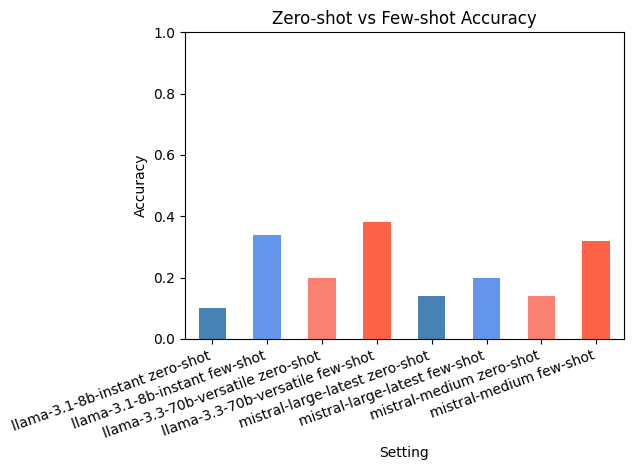

In [ ]:
def accuracy(preds, gold_labels):
    if not gold_labels:
        return 0.0
    return sum(p == g for p, g in zip(preds, gold_labels)) / len(gold_labels)


results = {
    "llama-3.1-8b-instant zero-shot":    accuracy(zs_groq_preds1,    gold_test),
    "llama-3.1-8b-instant few-shot":     accuracy(fs_groq_preds1,    gold_test),
    
    "llama-3.3-70b-versatile zero-shot":    accuracy(zs_groq_preds2,    gold_test),
    "llama-3.3-70b-versatile few-shot":     accuracy(fs_groq_preds2,    gold_test),
    
    "mistral-large-latest zero-shot": accuracy(zs_mistral_preds1,  gold_test),
    "mistral-large-latest few-shot":  accuracy(fs_mistral_preds1,  gold_test),

    "mistral-medium zero-shot": accuracy(zs_mistral_preds2,  gold_test),
    "mistral-medium few-shot":  accuracy(fs_mistral_preds2,  gold_test),
}

results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
display(results_df)

results_df.set_index("Model")["Accuracy"].plot(
    kind="bar",
    title="Zero-shot vs Few-shot Accuracy",
    ylim=(0, 1),
    color=["steelblue", "cornflowerblue", "salmon", "tomato"],
)
plt.ylabel("Accuracy")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

,Model,Accuracy
0,llama-3.1-8b-instant few-shot 1,0.34
1,llama-3.1-8b-instant few-shot 2,0.28
2,llama-3.3-70b-versatile few-shot 1,0.38
3,llama-3.3-70b-versatile few-shot 2,0.26
4,mistral-large-latest few-shot 1,0.20
5,mistral-large-latest few-shot 2,0.20
6,mistral-medium few-shot 1,0.32
7,mistral-medium few-shot 2,0.24


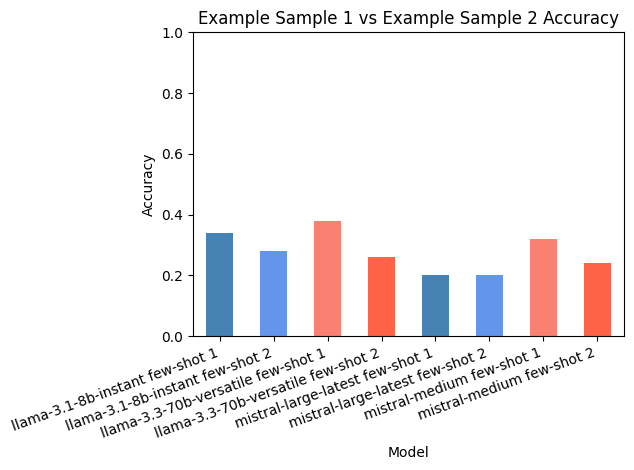

In [115]:
results = {
    "llama-3.1-8b-instant few-shot 1":     accuracy(fs_groq_preds1,    gold_test),
    "llama-3.1-8b-instant few-shot 2":     accuracy(fs_groq_preds11,    gold_test),
    
    "llama-3.3-70b-versatile few-shot 1":     accuracy(fs_groq_preds2,    gold_test),
    "llama-3.3-70b-versatile few-shot 2":     accuracy(fs_groq_preds22,    gold_test),
    
    "mistral-large-latest few-shot 1":  accuracy(fs_mistral_preds1,  gold_test),
    "mistral-large-latest few-shot 2":  accuracy(fs_mistral_preds11,  gold_test),

    "mistral-medium few-shot 1":  accuracy(fs_mistral_preds2,  gold_test),
    "mistral-medium few-shot 2":  accuracy(fs_mistral_preds22,  gold_test),
}

results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
display(results_df)

results_df.set_index("Model")["Accuracy"].plot(
    kind="bar",
    title="Example Sample 1 vs Example Sample 2 Accuracy",
    ylim=(0, 1),
    color=["steelblue", "cornflowerblue", "salmon", "tomato"],
)
plt.ylabel("Accuracy")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()